# Calculating enthalpy


your  name

In this assignment, we will write a program to calculate reaction enthaply. We choose the example in *Introduction to the Thermodynamics of Materials - Sixth Edition* by David R. Gaskell: Chapter 6 - the reaction of 

$$\text{Pb} + \frac{1}{2}\text{O}_2 = \text{PbO}.$$

The thermochemical data is given as below, which provides the formation enthalpy of PbO at 298 K, heat capacities of several substances, melting enthaply of Pb at metling point (600 K).

<div align="left">
<img src="https://i.ibb.co/VYsnSqvr/Tab1.png" width="600">
</div>


**Use these data, we will 1) plot the enthalpy curves as function of temperature**

Hint: recall the thermodynamics course.

1. Enthalpy of a pure substance at 298 K is set to be zero as a reference value.
2. Melting enthalpy is the enthalpy difference between the same substance in liquid and solid phases at melting point.

### Part 1. Calibrate the enthalpy values of pure substances at 298 K


1. Let's make some symbolic formulae of enthalpies for Pb. Enthalpy is the integration of $C_p$ over $T$.
$$H = \int C_p dT$$
3. Pure solid Pb at 298 K will be set to zero.
4. The enthalpy of liquid Pb is 4810 J higher than that of solid Pb at the 600 K.

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sp.init_printing(use_unicode=True)

In [5]:
T = sp.symbols('T')

H_m_Pb = 4810 
Tm_Pb = 600

# formula
Cp_Pbs = 23.6 + 9.75e-3 * T 
Cp_Pbl = 32.4 - 3.1e-3 * T

# enthalpy
H_Pbs = sp.integrate(Cp_Pbs, T)
H_Pbl = sp.integrate(Cp_Pbl, T)

# the reference values at 298 K 
Pbs_ref = H_Pbs.subs(T, 298)

# calibrated enthalpy functions of solid Pb
H_Pbs = H_Pbs - Pbs_ref 

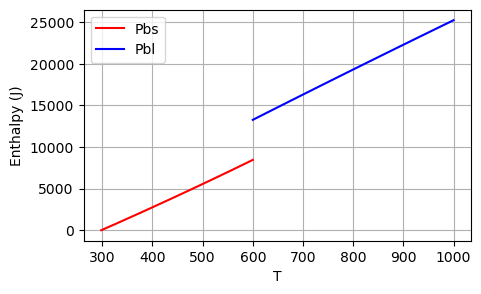

In [7]:
# liquid Pb at melting point will be equal to Pbs + dH
Pbl_ref = H_Pbl.subs(T, Tm_Pb)
H_Pbl = H_Pbl - Pbl_ref
H_Pbl = H_Pbl + H_Pbs.subs(T, Tm_Pb) + H_m_Pb

# visualize
H_Pbs_plt = sp.lambdify(T, H_Pbs, "numpy")
H_Pbl_plt = sp.lambdify(T, H_Pbl, "numpy")
Ts_vals = np.linspace(298, 600, 100)
Tl_vals = np.linspace(600, 1000, 100)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(Ts_vals, H_Pbs_plt(Ts_vals), 'r', label="Pbs")
ax.plot(Tl_vals, H_Pbl_plt(Tl_vals), 'b', label="Pbl")
ax.set_xlabel("T")
ax.set_ylabel("Enthalpy (J)")
ax.grid(True)
ax.legend()

4. For oxygen, again we set its H to be zero at 298 K.

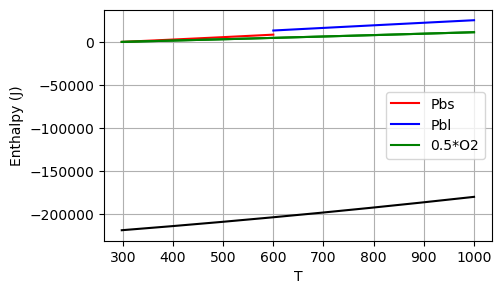

In [13]:
# formula
Cp_O2 = 29.96 + 4.18e-3 * T - 1.67e5/(T**2)
H_O2 = sp.integrate(Cp_O2, T)

# the reference values at 298 K 
H_O2_ref = H_O2.subs(T, 298)
H_O2 = H_O2 - H_O2_ref

H_O2_plt = sp.lambdify(T, H_O2, "numpy")
To_vals = np.linspace(298, 1000, 200)

# plot the enthalpy of 0.5*H_O2
ax.plot(To_vals, 0.5*H_O2_plt(To_vals), 'g', label="0.5*O2")

fig


### Part 2. Calibrate the enthalpy values of compound
5. Let's work on PbO. Since it's a compound, its enthalpy at 298 is not zero. The value is given in the table: -219000.

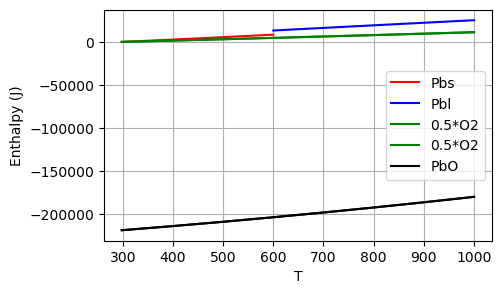

In [15]:
H_PbO_298 = -219000
# formula
Cp_PbO = 37.9 + 26.8e-3 * T

# enthalpy
H_PbO = sp.integrate(Cp_PbO, T)

# calibrate
H_PbO = H_PbO - H_PbO.subs(T, 298) + H_PbO_298

# visualize
H_PbO_plt = sp.lambdify(T, H_PbO, "numpy")
Tpo_vals = np.linspace(298, 1000, 200)

# plot the enthalpy of PbO
ax.plot(Tpo_vals, H_PbO_plt(Tpo_vals), 'k', label="PbO")
ax.legend()
fig

### Part 3. Reaction enthalpy 

**The reaction enthalpy is the sum of the total enthalpy of the reactants and the total enthalpy of the products.**

Write a function to calculate the reaction enthalpy of Pb oxidation at different temperatures.

- *Note that H of Pb_s (solid) is only valid in $T<600$ K, and that H of Pb_l (liquis) is valid only when $T>600$ K.**

In [31]:
def react_PbO(T_input):
    if T_input <= 600:
        dH_rxn = H_Pbs.subs(T, T_input) + 0.5*H_O2.subs(T, T_input) + H_PbO.subs(T, T_input)
    else:
        dH_rxn = H_Pbl.subs(T, T_input) + 0.5*H_O2.subs(T, T_input) + H_PbO.subs(T, T_input)
    return dH_rxn

- Make a plot of the reaction enthalpy in the range of $298 < T< 1000$.

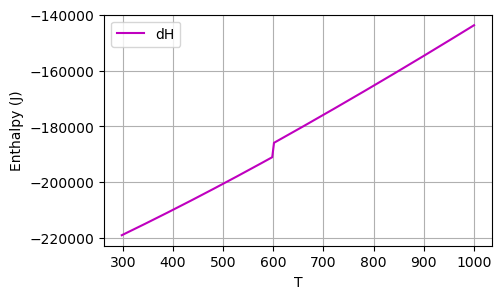

In [40]:
T_vals = np.linspace(298, 1000, 200)
dH = np.zeros_like(T_vals)

for i in range(len(dH)):
    dH[i] = react_PbO(T_vals[i])

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(T_vals, dH, 'm', label="dH")
ax.set_xlabel("T")
ax.set_ylabel("Enthalpy (J)")
ax.grid(True)
ax.legend()